<a href="https://colab.research.google.com/github/ilichnegrete-oss/Proyecto-Final-Proyecto-RappiPlus/blob/main/Olist_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# 1. Definir la ruta exacta basada en tu panel de Google Drive
ruta_carpeta = '/content/drive/MyDrive/Olist/'

# 2. Cargar las tablas del dataset
orders_df    = pd.read_csv(ruta_carpeta + 'olist_orders_dataset.csv')
items_df     = pd.read_csv(ruta_carpeta + 'olist_order_items_dataset.csv')
payments_df  = pd.read_csv(ruta_carpeta + 'olist_order_payments_dataset.csv')
products_df  = pd.read_csv(ruta_carpeta + 'olist_products_dataset.csv')
customers_df = pd.read_csv(ruta_carpeta + 'olist_customers_dataset.csv')
reviews_df   = pd.read_csv(ruta_carpeta + 'olist_order_reviews_dataset.csv')

# 3. Confirmación
print(f"Total de órdenes cargadas: {len(orders_df):,}")

# Ver las primeras 5 filas de la tabla de órdenes
orders_df.head()

Total de órdenes cargadas: 99,441


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
# 1. Agrupar la tabla de ítems por orden para obtener el valor total por pedido
aov_por_orden = items_df.groupby('order_id').agg(
    total_productos=('price', 'sum'),
    total_flete=('freight_value', 'sum')
).reset_index()

In [ ]:
# 2. Calcular el monto total sumando productos + flete
aov_por_orden['monto_total_orden'] = aov_por_orden['total_productos'] + aov_por_orden['total_flete']

In [ ]:
# 3. Calcular el Ticket Promedio General (AOV)
aov_general = aov_por_orden['monto_total_orden'].mean()
ticket_producto_promedio = aov_por_orden['total_productos'].mean()
flete_promedio = aov_por_orden['total_flete'].mean()

In [ ]:
print(f"---  METRICAS DE TICKET PROMEDIO ---")
print(f"Ticket Promedio Total (AOV): R$ {aov_general:.2f}")
print(f"Promedio gastado en Producto: R$ {ticket_producto_promedio:.2f}")
print(f"Promedio gastado en Flete:    R$ {flete_promedio:.2f}")

---  METRICAS DE TICKET PROMEDIO ---
Ticket Promedio Total (AOV): R$ 160.58
Promedio gastado en Producto: R$ 137.75
Promedio gastado en Flete:    R$ 22.82


In [ ]:
embudo = orders_df['order_status'].value_counts().reset_index()
embudo.columns = ['Estado_Orden', 'Cantidad']

# 2. Porcentaje sobre el total de órdenes
total_ordenes = len(orders_df)
embudo['Porcentaje'] = (embudo['Cantidad'] / total_ordenes * 100).round(2)

print(f"---  EMBUDO DE ESTADOS DE PEDIDO (Total: {total_ordenes:,}) ---")
print(embudo.to_string(index=False))

---  EMBUDO DE ESTADOS DE PEDIDO (Total: 99,441) ---
Estado_Orden  Cantidad  Porcentaje
   delivered     96478       97.02
     shipped      1107        1.11
    canceled       625        0.63
 unavailable       609        0.61
    invoiced       314        0.32
  processing       301        0.30
     created         5        0.01
    approved         2        0.00


/tmp/ipykernel_1657/1974658969.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


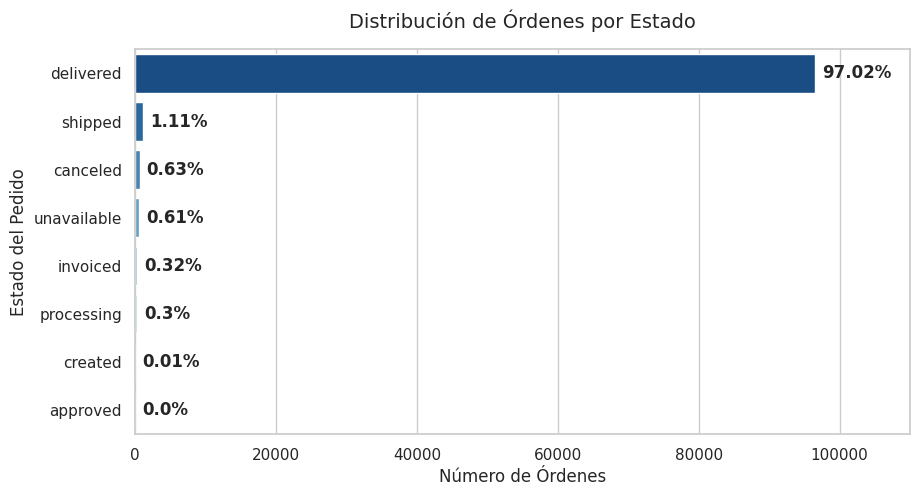

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Crear el gráfico de barras
ax = sns.barplot(
    data=embudo,
    x='Cantidad',
    y='Estado_Orden',
    palette='Blues_r'
)

# Agregar las etiquetas de porcentaje al final de cada barra
for i, row in embudo.iterrows():
    ax.text(row['Cantidad'] + 1000, i, f"{row['Porcentaje']}%", va='center', fontweight='bold')

plt.title('Distribución de Órdenes por Estado', fontsize=14, pad=15)
plt.xlabel('Número de Órdenes')
plt.ylabel('Estado del Pedido')
plt.xlim(0, 110000) # Espacio para que quepa el texto del porcentaje

plt.show()

/tmp/ipykernel_1657/940676178.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


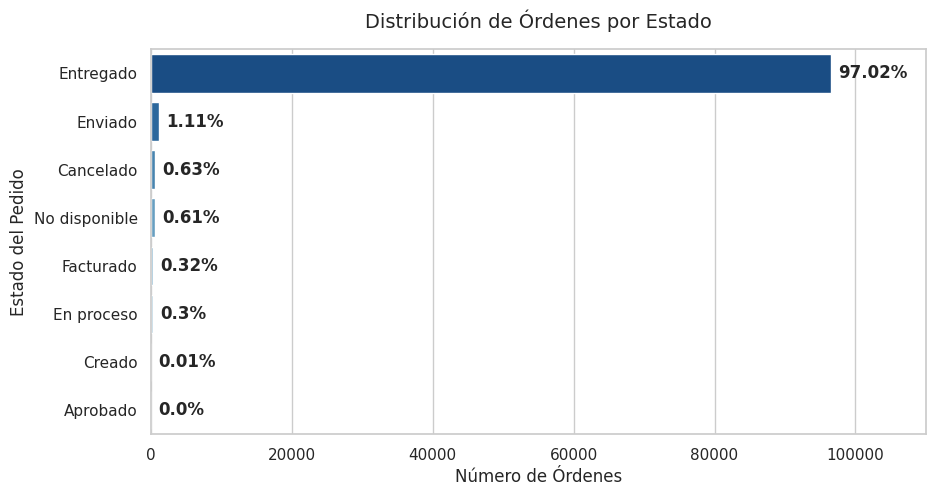

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Traducir los nombres al español
traduccion_estados = {
    'delivered': 'Entregado',
    'shipped': 'Enviado',
    'canceled': 'Cancelado',
    'unavailable': 'No disponible',
    'invoiced': 'Facturado',
    'processing': 'En proceso',
    'created': 'Creado',
    'approved': 'Aprobado'
}

embudo['Estado_Orden'] = embudo['Estado_Orden'].replace(traduccion_estados)

# 2. Configurar el estilo visual
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# 3. Crear el gráfico de barras
ax = sns.barplot(
    data=embudo,
    x='Cantidad',
    y='Estado_Orden',
    palette='Blues_r'
)

# 4. Agregar los porcentajes al final de cada barra
for i, row in embudo.iterrows():
    ax.text(row['Cantidad'] + 1000, i, f"{row['Porcentaje']}%", va='center', fontweight='bold')

# 5. Títulos y etiquetas en español
plt.title('Distribución de Órdenes por Estado', fontsize=14, pad=15)
plt.xlabel('Número de Órdenes')
plt.ylabel('Estado del Pedido')
plt.xlim(0, 110000)

plt.show()

In [ ]:
# 1. Convertir columnas de texto a formato de fecha (datetime)
fechas_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in fechas_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# 2. Filtrar solo pedidos entregados para medir tiempos reales
entregados = orders_df[orders_df['order_status'] == 'delivered'].copy()

# 3. Calcular días reales de entrega y días prometidos por la plataforma
entregados['dias_entrega_real'] = (entregados['order_delivered_customer_date'] - entregados['order_purchase_timestamp']).dt.days
entregados['dias_entrega_estimados'] = (entregados['order_estimated_delivery_date'] - entregados['order_purchase_timestamp']).dt.days

# 4. Verificar si hubo retraso (1 si se entregó después de la fecha estimada, 0 si llegó a tiempo)
entregados['con_retraso'] = entregados['order_delivered_customer_date'] > entregados['order_estimated_delivery_date']

print("---  TIEMPOS Y CUMPLIMIENTO DE ENTREGA ---")
print(f"Tiempo promedio de entrega: {entregados['dias_entrega_real'].mean():.1f} días")
print(f"Tiempo estimado promedio:   {entregados['dias_entrega_estimados'].mean():.1f} días")
print(f"Porcentaje de entregas a tiempo: {((1 - entregados['con_retraso'].mean()) * 100):.2f}%")

---  TIEMPOS Y CUMPLIMIENTO DE ENTREGA ---
Tiempo promedio de entrega: 12.1 días
Tiempo estimado promedio:   23.4 días
Porcentaje de entregas a tiempo: 91.89%


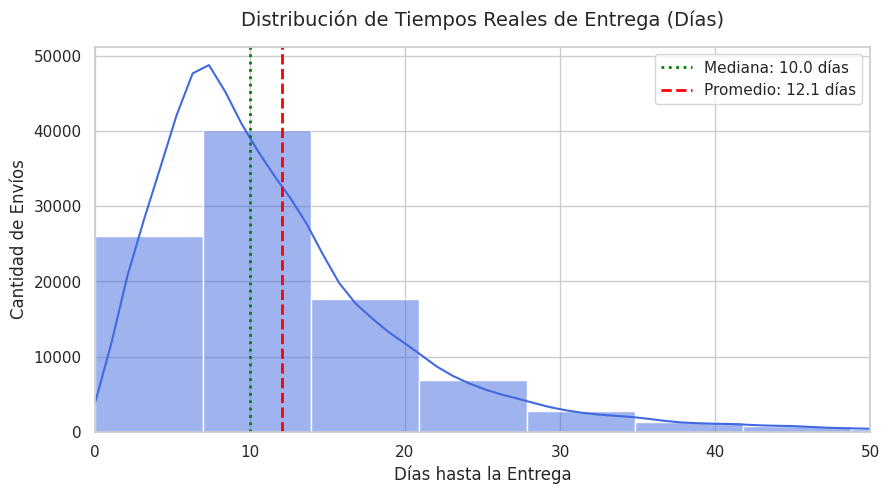

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Crear el histograma con curva de densidad (KDE)
sns.histplot(
    data=entregados,
    x='dias_entrega_real',
    bins=30,
    kde=True,
    color='royalblue'
)

# Línea vertical para marcar el promedio
promedio = entregados['dias_entrega_real'].mean()
mediana = entregados['dias_entrega_real'].median()
plt.axvline(mediana, color='green', linestyle=':', linewidth=2, label=f'Mediana: {mediana:.1f} días')
plt.axvline(promedio, color='red', linestyle='--', linewidth=2, label=f'Promedio: {promedio:.1f} días')

plt.title('Distribución de Tiempos Reales de Entrega (Días)', fontsize=14, pad=15)
plt.xlabel('Días hasta la Entrega')
plt.ylabel('Cantidad de Envíos')
plt.xlim(0, 50) # Limitamos a 50 días para ver el grueso de los datos
plt.legend()

plt.show()

In [ ]:
# 1. Unir la tabla de ítems con la de pedidos y clientes
ventas_geograficas = items_df.merge(orders_df[['order_id', 'customer_id']], on='order_id')
ventas_geograficas = ventas_geograficas.merge(customers_df[['customer_id', 'customer_state', 'customer_city']], on='customer_id')

# 2. Agrupar por Estado del Cliente
ventas_estado = ventas_geograficas.groupby('customer_state').agg(
    total_ventas=('price', 'sum'),
    total_flete=('freight_value', 'sum'),
    total_pedidos=('order_id', 'nunique')
).reset_index()

# 3. Calcular el Ticket Promedio por Estado
ventas_estado['ticket_promedio'] = ventas_estado['total_ventas'] / ventas_estado['total_pedidos']

# 4. Ordenar de mayor a menor según la facturación total
ventas_estado = ventas_estado.sort_values(by='total_ventas', ascending=False)

# Mostrar el Top 10 de estados con mayor facturación
print("---  TOP 10 ESTADOS POR FACTURACIÓN ---")
top_10 = ventas_estado.head(10).copy()
top_10['total_ventas_fmt'] = top_10['total_ventas'].apply(lambda x: f"R$ {x:,.2f}")
top_10['ticket_promedio_fmt'] = top_10['ticket_promedio'].apply(lambda x: f"R$ {x:.2f}")

print(top_10[['customer_state', 'total_pedidos', 'total_ventas_fmt', 'ticket_promedio_fmt']].to_string(index=False))

---  TOP 10 ESTADOS POR FACTURACIÓN ---
customer_state  total_pedidos total_ventas_fmt ticket_promedio_fmt
            SP          41375  R$ 5,202,955.05           R$ 125.75
            RJ          12762  R$ 1,824,092.67           R$ 142.93
            MG          11544  R$ 1,585,308.03           R$ 137.33
            RS           5432    R$ 750,304.02           R$ 138.13
            PR           4998    R$ 683,083.76           R$ 136.67
            SC           3612    R$ 520,553.34           R$ 144.12
            BA           3358    R$ 511,349.99           R$ 152.28
            DF           2125    R$ 302,603.94           R$ 142.40
            GO           2007    R$ 294,591.95           R$ 146.78
            ES           2025    R$ 275,037.31           R$ 135.82


/tmp/ipykernel_1657/2194643080.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


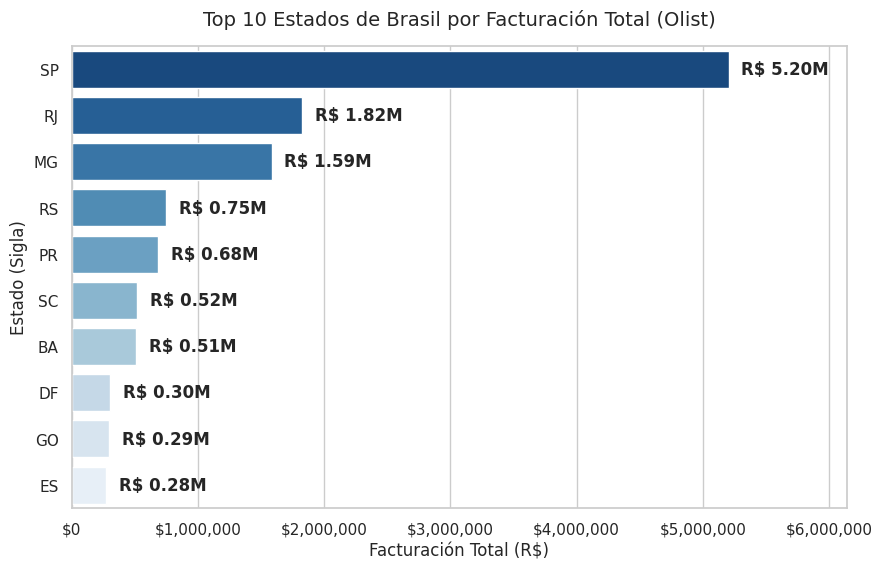

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Graficar el Top 10 de Estados
ax = sns.barplot(
    data=top_10,
    x='total_ventas',
    y='customer_state',
    palette='Blues_r'
)

# Formatear el eje X para mostrar valores en millones (R$)
ax.xaxis.set_major_formatter('${x:,.0f}')

plt.title('Top 10 Estados de Brasil por Facturación Total (Olist)', fontsize=14, pad=15)
plt.xlabel('Facturación Total (R$)')
plt.ylabel('Estado (Sigla)')

# Mostrar los valores exactos sobre cada barra
for i, row in top_10.reset_index(drop=True).iterrows():
    ax.text(row['total_ventas'] + 100000, i, f"R$ {row['total_ventas']/1e6:.2f}M", va='center', fontweight='bold')

plt.xlim(0, top_10['total_ventas'].max() * 1.18)
plt.show()

In [ ]:
# 1. Conteo de transacciones por método de pago
pagos = payments_df['payment_type'].value_counts().reset_index()
pagos.columns = ['Metodo_Pago', 'Cantidad']

# 2. Porcentaje sobre el total de pagos
pagos['Porcentaje'] = (pagos['Cantidad'] / len(payments_df) * 100).round(2)

# 3. Traducir los métodos al español
traduccion_pagos = {
    'credit_card': 'Tarjeta de Crédito',
    'boleto': 'Boleto Bancario',
    'voucher': 'Voucher / Cupones',
    'debit_card': 'Tarjeta de Débito',
    'not_defined': 'No Definido'
}
pagos['Metodo_Pago'] = pagos['Metodo_Pago'].replace(traduccion_pagos)

print("---  MÉTODOS DE PAGO PREFERIDOS ---")
print(pagos.to_string(index=False))

---  MÉTODOS DE PAGO PREFERIDOS ---
       Metodo_Pago  Cantidad  Porcentaje
Tarjeta de Crédito     76795       73.92
   Boleto Bancario     19784       19.04
 Voucher / Cupones      5775        5.56
 Tarjeta de Débito      1529        1.47
       No Definido         3        0.00


In [ ]:
# 1. Conteo de calificaciones
reviews_summary = reviews_df['review_score'].value_counts().reset_index()
reviews_summary.columns = ['Estrellas', 'Cantidad']

# 2. Porcentaje sobre el total de reseñas
reviews_summary['Porcentaje'] = (reviews_summary['Cantidad'] / len(reviews_df) * 100).round(2)

# 3. Ordenar de 5 a 1 estrella
reviews_summary = reviews_summary.sort_values(by='Estrellas', ascending=False)

print("---  SATISFACCIÓN DEL CLIENTE (RESEÑAS) ---")
print(reviews_summary.to_string(index=False))

---  SATISFACCIÓN DEL CLIENTE (RESEÑAS) ---
 Estrellas  Cantidad  Porcentaje
         5     57328       57.78
         4     19142       19.29
         3      8179        8.24
         2      3151        3.18
         1     11424       11.51


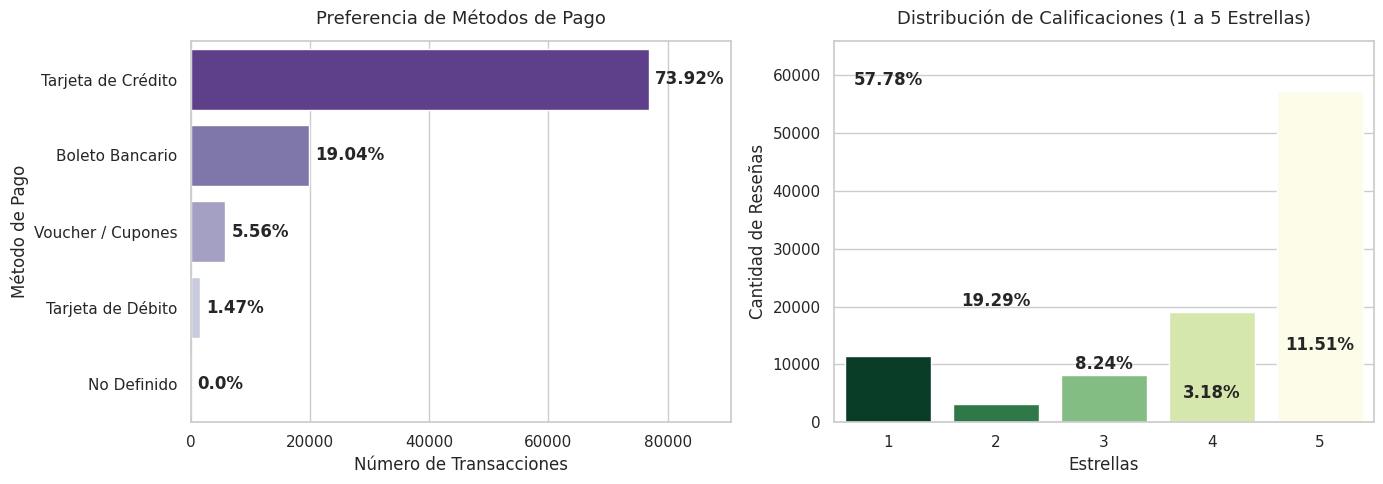

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Gráfico 1: Métodos de Pago
sns.barplot(
    data=pagos,
    x='Cantidad',
    y='Metodo_Pago',
    hue='Metodo_Pago',
    legend=False,
    palette='Purples_r',
    ax=axes[0]
)
axes[0].set_title('Preferencia de Métodos de Pago', fontsize=13, pad=12)
axes[0].set_xlabel('Número de Transacciones')
axes[0].set_ylabel('Método de Pago')

for i, row in pagos.iterrows():
    axes[0].text(row['Cantidad'] + 1000, i, f"{row['Porcentaje']}%", va='center', fontweight='bold')

axes[0].set_xlim(0, pagos['Cantidad'].max() * 1.18)

# Gráfico 2: Reseñas
sns.barplot(
    data=reviews_summary,
    x='Estrellas',
    y='Cantidad',
    hue='Estrellas',
    legend=False,
    palette='YlGn_r',
    ax=axes[1]
)
axes[1].set_title('Distribución de Calificaciones (1 a 5 Estrellas)', fontsize=13, pad=12)
axes[1].set_xlabel('Estrellas')
axes[1].set_ylabel('Cantidad de Reseñas')

for i, row in reviews_summary.reset_index(drop=True).iterrows():
    axes[1].text(i, row['Cantidad'] + 1000, f"{row['Porcentaje']}%", ha='center', fontweight='bold')

axes[1].set_ylim(0, reviews_summary['Cantidad'].max() * 1.15)

plt.tight_layout()
plt.show()

#  Conclusiones Generales y Recomendaciones de Negocio

---

##  Resumen Ejecutivo

El presente análisis integral de la operación de e-commerce (**Olist**) permitió evaluar el desempeño comercial, la eficiencia logística, la cobertura geográfica y la satisfacción del cliente a partir del procesamiento de datos transaccionales.

A través del pipeline de análisis y visualización, se identificaron patrones operativos clave que destacan fortalezas estructurales, así como cuellos de botella que representan oportunidades directas de optimización.

---

##  Hallazgos Clave (Key Insights)

1. **Eficiencia en el Embudo Operativo:**
   * **Alta Tasa de Éxito:** El **97.02%** de los pedidos realizados completan su ciclo hasta la entrega exitosa.
   * **Baja Cancelación:** La tasa de cancelación se mantiene baja (**0.63%**), lo que refleja alta estabilidad en el procesamiento de órdenes.

2. **Desempeño Logístico y Variabilidad:**
   * **Tiempo Típico (Mediana):** El 50% de los clientes recibe su pedido en **10.0 días** o menos.
   * **Efecto de Casos Extremos:** El tiempo promedio de entrega se eleva a **12.1 días** debido a una distribución con sesgo a la derecha (*right-skewed*), impulsada por envíos a regiones distantes que pueden tardar de 30 a 50 días.

3. **Concentración Geográfica de Ventas:**
   * **Dominio de São Paulo (`SP`):** Lidera ampliamente la facturación total con **R$ 5.20M**, generando casi el triple de ingresos que el segundo estado (`RJ` con R$ 1.82M).
   * **Región Sudeste:** Los estados de **SP, RJ y MG** concentran la mayor parte de la masa financiera del negocio, evidenciando una fuerte dependencia comercial de esta zona geográfica.

4. **Patrones de Pago y Satisfacción:**
   * **Preferencia de Crédito (73.92%):** Casi 3 de cada 4 compras se realizan con tarjeta de crédito, lo que reafirma la importancia del financiamiento en cuotas (*parcelas*) para impulsar la conversión.
   * **Percepción Positiva del Cliente:** El **77.07%** de los usuarios otorga calificaciones de 4 o 5 estrellas (**57.78%** corresponden a 5 estrellas).
   * **Punto de Dolor (11.51%):** Las reseñas negativas (1 estrella) representan más del 11% de la muestra, estando fuertemente asociadas a retrasos en las entregas del extremo largo de la curva logística.

---

##  Recomendaciones Estratégicas

1. **Optimización Logística por Regiones (Reducción de la "Cola Larga"):**
   * Establecer alianzas estratégicas o centros de distribución secundarios (*hubs*) en regiones como el Nordeste o Sur para reducir los tiempos de envío extremos (>20 días) y disminuir la insatisfacción que impacta las reseñas de 1 estrella.

2. **Estrategia Comercial Fuera de la Región Central:**
   * Diseñar campañas de marketing focalizadas y subsidios progresivos de flete en estados de alto potencial como **BA** (Bahía) y **DF** (Distrito Federal) para diversificar los ingresos más allá del estado de São Paulo.

3. **Flexibilidad en Opciones de Financiamiento:**
   * Mantener e incentivar alianzas con procesadores de pago que ofrezcan cuotas sin interés en tarjetas de crédito, dado que representan cerca del 74% del volumen transaccional de la plataforma.